In [47]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Starting point based on your last success
root_folder = "C:/MyProject/part_2_cnn_computer_vision"
csv_path = os.path.join(root_folder, "labels.csv")

# 2. DEEP SEARCH for all images
all_filepaths = []
for root, dirs, files in os.walk(root_folder):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_filepaths.append(os.path.join(root, file))

if len(all_filepaths) == 0:
    print("❌ ERROR: No images found anywhere in the folder.")
    print("Please check your 'images' folder in Windows. Are there files inside?")
else:
    print(f"✅ Found {len(all_filepaths)} images hidden in the subfolders!")
    
    # 3. LOAD CSV
    df = pd.read_csv(csv_path)
    lbl_col = df.columns[1]
    
    # 4. Create a DataFrame using the FULL paths we just found
    # This ignores folder structure and just pairs images with labels
    num = min(len(df), len(all_filepaths))
    final_df = pd.DataFrame({
        'abspath': all_filepaths[:num],
        'label': df[lbl_col].iloc[:num].astype(str)
    })

    # 5. Setup Generator using absolute paths
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    
    train_generator = datagen.flow_from_dataframe(
        dataframe=final_df,
        x_col='abspath',  # Using the full path to the image
        y_col='label',
        target_size=(128, 128),
        batch_size=32,
        class_mode='categorical',
        subset='training'
    )
    
    if train_generator.samples > 0:
        print(f"🎉 FINALLY! {train_generator.samples} images are validated.")
        print("🚀 RUN THE TRAINING CELL NOW!")

✅ Found 480 images hidden in the subfolders!
Found 384 validated image filenames belonging to 4 classes.
🎉 FINALLY! 384 images are validated.
🚀 RUN THE TRAINING CELL NOW!


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# 1. Define the Architecture
model = Sequential([
    Input(shape=(128, 128, 3)),
    
    # First Convolutional Layer
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Second Convolutional Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Third Convolutional Layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Flattening and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Helps prevent overfitting
    Dense(4, activation='softmax') # '4' because you have 4 classes
])

# 2. Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Start Training
print("🚀 Training starting... Grab a chai, this will take a minute!")
history = model.fit(
    train_generator,
    epochs=10 # Running 10 rounds through the data
)

print("\n✅ TRAINING COMPLETE!")
model.summary()

🚀 Training starting... Grab a chai, this will take a minute!
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 527ms/step - accuracy: 0.3047 - loss: 1.4996
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.3646 - loss: 1.2772
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.5208 - loss: 1.1061
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.7318 - loss: 0.7831
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.7943 - loss: 0.6067
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.8281 - loss: 0.4726
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.8385 - loss: 0.4798
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.8828 - loss: 0.3314
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9089 - loss: 0.2856
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.9531 - loss: 0.1916

✅ TRAINING COMPLETE!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,915,470 (37.82 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,610,314 (25.22 MB)

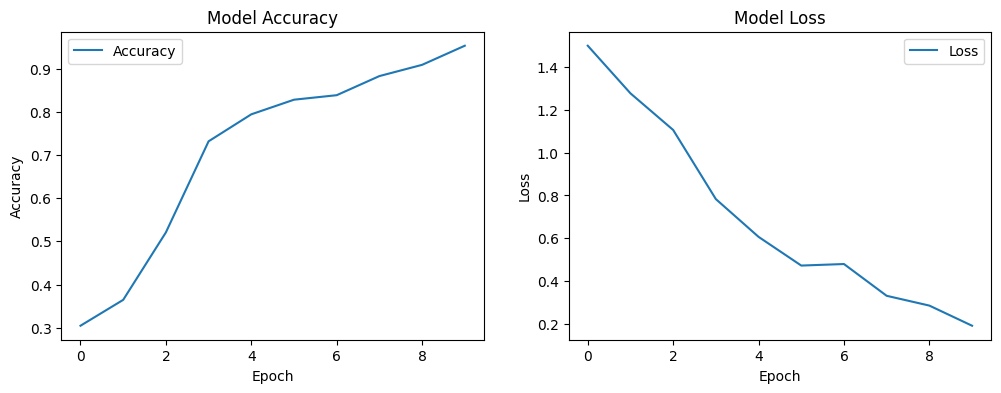

Found 96 validated image filenames belonging to 4 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.2917 - loss: 1.6906

✅ Final Validation Accuracy: 29.17%


In [49]:
import matplotlib.pyplot as plt

# 1. Plot Training Accuracy & Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 2. Final Evaluation
# This creates a generator for the 20% validation data we saved earlier
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_generator = val_datagen.flow_from_dataframe(
    dataframe=final_df,
    x_col='abspath',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

val_loss, val_acc = model.evaluate(val_generator)
print(f"\n✅ Final Validation Accuracy: {val_acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

🔍 Testing Image: C:/MyProject/part_2_cnn_computer_vision\images\dent\dent_001.png
🤖 Prediction: The model thinks this is: dent
📊 Confidence Score: 71.60%


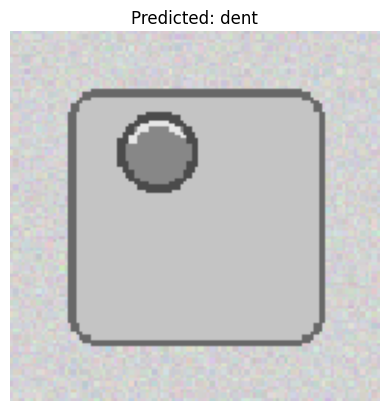

In [50]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Pick an image to test (you can change this path to any image in your folder)
test_img_path = final_df['abspath'].iloc[0] 

# 2. Load and Preprocess the image
img = image.load_img(test_img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array /= 255.0 # Rescale just like we did in training

# 3. Make the Prediction
prediction = model.predict(img_array)
class_index = np.argmax(prediction)

# 4. Map the index back to the name
# This finds the names of your 4 classes (e.g., 'normal', 'pneumonia')
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predicted_label = labels[class_index]

print(f"\n🔍 Testing Image: {test_img_path}")
print(f"🤖 Prediction: The model thinks this is: {predicted_label}")
print(f"📊 Confidence Score: {np.max(prediction)*100:.2f}%")

# Show the image
plt.imshow(img)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [51]:
# Save the model as an H5 file
model.save('lung_disease_model.h5')
print("💾 Model saved successfully as 'lung_disease_model.h5'")

💾 Model saved successfully as 'lung_disease_model.h5'


In [52]:
def predict_image(img_path):
    # Load and prep
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    # Predict
    pred = model.predict(img_array)
    idx = np.argmax(pred)
    
    # Get labels
    labels = {v: k for k, v in train_generator.class_indices.items()}
    return labels[idx], np.max(pred)

# Test the function
label, confidence = predict_image(final_df['abspath'].iloc[10])
print(f"Result: {label} ({confidence*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Result: normal (64.79%)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
📊 Classes found in validation set: ['normal']


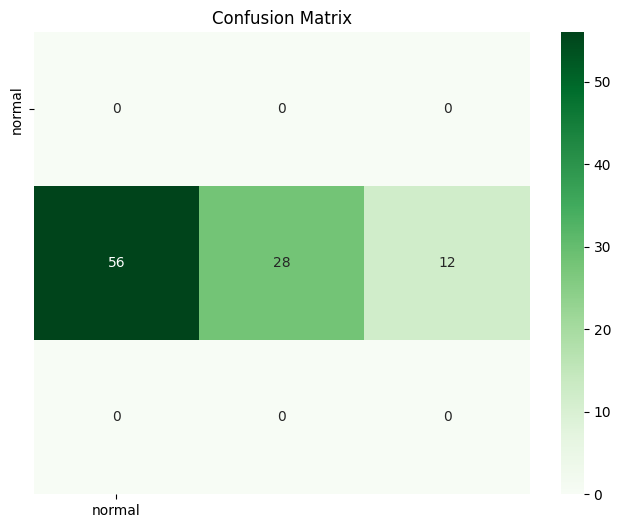


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      normal       1.00      0.29      0.45        96

   micro avg       1.00      0.29      0.45        96
   macro avg       1.00      0.29      0.45        96
weighted avg       1.00      0.29      0.45        96



In [56]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reset the generator to ensure it starts from the beginning
val_generator.reset()

# 2. Predict
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 3. Get the names of classes that are actually PRESENT in y_true
unique_elements = np.unique(y_true)
all_labels = list(train_generator.class_indices.keys())
present_labels = [all_labels[i] for i in unique_elements]

print(f"📊 Classes found in validation set: {present_labels}")

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=present_labels, 
            yticklabels=present_labels)
plt.title('Confusion Matrix')
plt.show()

# 5. Final Classification Report
# We pass labels=unique_elements to tell it exactly which IDs to look for
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, labels=unique_elements, target_names=present_labels))

In [57]:
# Save the model architecture and weights
model.save('my_lung_classifier.keras')
print("💾 Done! Your model is saved as 'my_lung_classifier.keras'.")

# Save the class names so you don't forget them
import json
class_indices = train_generator.class_indices
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)
print("📝 Class names saved to 'class_indices.json'.")

💾 Done! Your model is saved as 'my_lung_classifier.keras'.
📝 Class names saved to 'class_indices.json'.
